<a href="https://colab.research.google.com/github/anarghya-04/ICSSL/blob/main/ICSSL7_logistic_regression_and_kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic regression

In [52]:
# Import necessary packages
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import zipfile
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.inspection import DecisionBoundaryDisplay

In [12]:
iris = load_iris()
X = iris.data[:, :4]
y = iris.target
type(X)
print(X.shape)

(150, 4)


Perform Logisitic Regression and kNN on this dataset following the below steps:

1.  Preprocess the data
    * Check for empty values or nulls and perform necessary imputations/deletions
    * Encode the class variable numerically using the label encoder
    * Scale features as necessary

In [22]:
scaler = StandardScaler()
X_transformed = scaler.fit_transform(X)
X_transformed

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [24]:
print(X_transformed.shape)

(150, 4)


In [33]:
#Checking for null values
rows_with_na = np.isnan(X).sum()
print("\nRows containing NAs:")
rows_with_na


Rows containing NAs:


np.int64(0)

2. Logistic regression
    * Create a logistic regression model
    * Fit the logistic regression model to the train data
    * Get predictions for the class variable (y)
    * Get the train accuracy and test accuracy. Here accuracy is basically the fraction of correctly classified samples, i.e., y_pred==y_true.

In [42]:
#Logistic regression model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=50)

#Fitting using the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [44]:
#Accuracy: if it is 1, the regression model is predicting your test values correctly. The predicted value equal the true values
accuracy_test = accuracy_score(y_test,y_pred_test)
accuracy_test


0.9833333333333333

In [46]:
#Classification Report
class_report = classification_report(y_test,y_pred_test)
class_report

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        21\n           1       1.00      0.95      0.98        21\n           2       0.95      1.00      0.97        18\n\n    accuracy                           0.98        60\n   macro avg       0.98      0.98      0.98        60\nweighted avg       0.98      0.98      0.98        60\n'

In [45]:
#Confusion Matrix: number of correct and incorrect predictions summed up class-wise.
conf_matrix = confusion_matrix(y_test, y_pred_test)
conf_matrix

array([[21,  0,  0],
       [ 0, 20,  1],
       [ 0,  0, 18]])

Text(0.5, 427.9555555555555, 'Predicted')

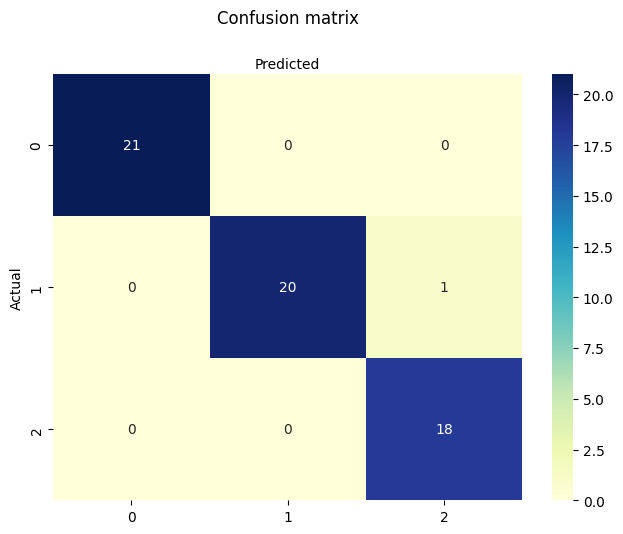

In [54]:
#visualising the confusion matrix
class_names=[0,1,2] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual')
plt.xlabel('Predicted')

3. Plotting the decision boundaries for Logistic Regression
    * Create scatter plots taking any two features at a time
    * Plot the decision boundary using sklearn's DecisionBoundaryDisplay

In [ ]:
#Plotting the Decision Boundary
fig, ax = plt.subplots
disp = DecisionBoundaryDisplay.from_estimator()
disp.ax.scatter()

4. kNN
    * Create a kNN model
    * Fit the kNN to the train data
    * Get predictions for the class variable (y)
    * Get the train accuracy and test accuracy. Here accuracy is basically the fraction of correctly classified samples, i.e., y_pred==y_true.

5. Plotting the decision boundaries for Logistic Regression
    * Create scatter plots taking any two features at a time
    * Plot the decision boundary using sklearn's DecisionBoundaryDisplay